<a href="https://colab.research.google.com/github/14marcos1/curso_colab_2026/blob/main/DataSUS002.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
pip install PySUS pandas

## Prompt:

"Escreva um script em Python para o Google Colab usando pandas, matplotlib e seaborn para gerar um gráfico de linha a partir do arquivo mortalidade_acre_2010_2023.csv.

Instruções de código e design:

Agrupamento de Dados: Leia o CSV e agrupe a contagem total de óbitos por ANO_OBITO e GRUPO_CAUSA, criando uma coluna OBITOS.

Estilo do Gráfico:

Use o tema whitegrid do Seaborn e tamanho de figura (12, 6.5).

Defina cores personalizadas para a paleta: Laranja (#d95f02) para 'Doenças do Aparelho Circulatório' e Roxo (#7570b3) para 'Neoplasias'.

Plote o gráfico de linhas com marcadores circulares (o), espessura de linha 2.5 e tamanho de marcador 8.

Hierarquia de Títulos (Sem sobreposição):

Crie um título principal usando plt.suptitle() com fonte em negrito tamanho 16 e posição y=0.98.

Crie um subtítulo usando plt.title() com o texto 'Acre (AC) — 2010 a 2023 | Fonte: DataSUS (SIM)', cor cinza (#555555) e pad=15.

Aplique plt.tight_layout() e plt.subplots_adjust(top=0.88) para garantir margem superior e evitar que os títulos fiquem embolados.

Anotações e Eixos:

Configure os eixos com plt.xlabel() e plt.ylabel(). Garanta que todos os anos apareçam no eixo X com plt.xticks().

Adicione o valor exato do número de óbitos em texto acima de cada ponto do gráfico via ax.annotate().

Legenda e Exportação:

Posicione a legenda no canto superior esquerdo (upper left) com fundo branco semi-transparente e borda.

Salve a imagem final como grafico_mortalidade_acre.png com 300 dpi e exiba o gráfico na tela."

/tmp/ipykernel_4456/2160746989.py:6: DtypeWarning: Columns (54,98) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("mortalidade_acre_2010_2023.csv")


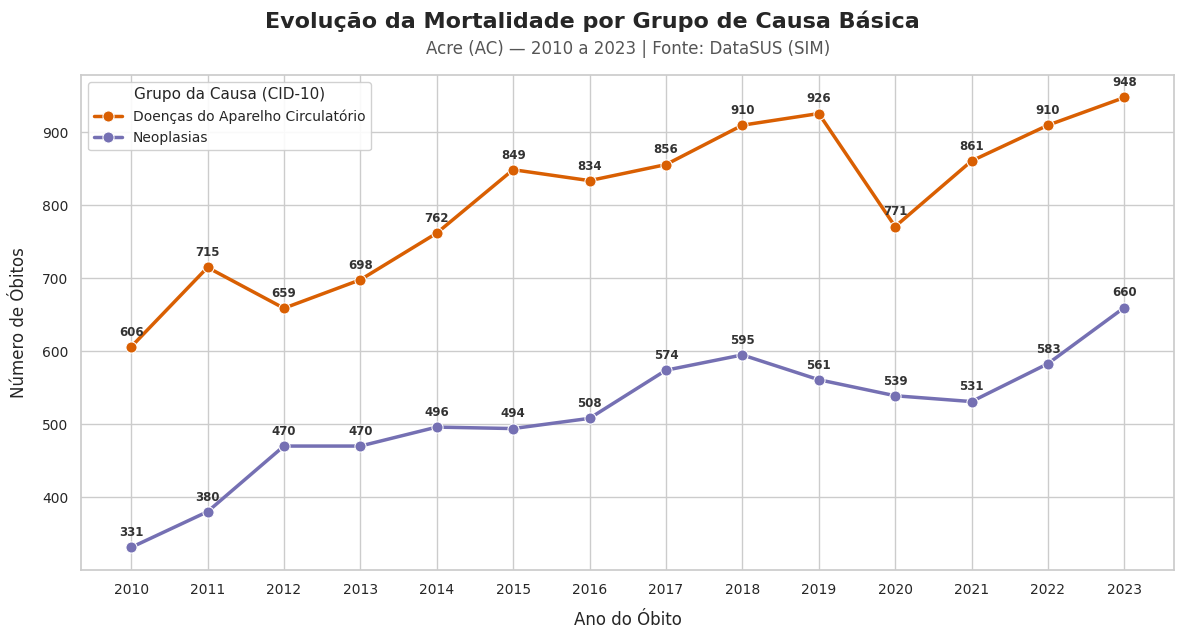

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carrega o arquivo CSV gerado anteriormente
df = pd.read_csv("mortalidade_acre_2010_2023.csv")

# 2. Agrupa a contagem de óbitos por Ano e por Causa
df_grouped = df.groupby(['ANO_OBITO', 'GRUPO_CAUSA']).size().reset_index(name='OBITOS')

# 3. Configuração visual do gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6.5))

# Definindo cores específicas
cores = {
    'Doenças do Aparelho Circulatório': '#d95f02',
    'Neoplasias': '#7570b3'
}

# Plotagem das linhas
ax = sns.lineplot(
    data=df_grouped,
    x='ANO_OBITO',
    y='OBITOS',
    hue='GRUPO_CAUSA',
    marker='o',
    linewidth=2.5,
    markersize=8,
    palette=cores
)

# 4. Ajuste dos Títulos (Hierarquia clara para não embolar)
plt.suptitle(
    'Evolução da Mortalidade por Grupo de Causa Básica',
    fontsize=16,
    fontweight='bold',
    y=0.98
)
plt.title(
    'Acre (AC) — 2010 a 2023 | Fonte: DataSUS (SIM)',
    fontsize=12,
    color='#555555',
    pad=15
)

# 5. Formatação dos eixos e rótulos
plt.xlabel('Ano do Óbito', fontsize=12, labelpad=10)
plt.ylabel('Número de Óbitos', fontsize=12, labelpad=10)
plt.xticks(df_grouped['ANO_OBITO'].unique(), fontsize=10)
plt.yticks(fontsize=10)

# Add rótulos numéricos nos pontos para facilitar a leitura
for _, row in df_grouped.iterrows():
    ax.annotate(
        f"{row['OBITOS']}",
        (row['ANO_OBITO'], row['OBITOS']),
        textcoords="offset points",
        xytext=(0, 8),
        ha='center',
        fontsize=8.5,
        fontweight='bold',
        color='#333333'
    )

# Legenda bem posicionada
plt.legend(
    title='Grupo da Causa (CID-10)',
    title_fontsize='11',
    fontsize='10',
    loc='upper left',
    frameon=True,
    facecolor='white',
    framealpha=0.9
)

# Margem superior garantida para evitar corte ou sobreposição do título
plt.tight_layout()
plt.subplots_adjust(top=0.88)

# 6. Exibir e salvar a imagem em alta resolução
plt.savefig('grafico_mortalidade_acre.png', dpi=300)
plt.show()